In [23]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm

In [44]:
file = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7465783/sum_cevns_full.root")
tree = file["Primary"]
tree2 = file["PrimaryPhononTracks"]
#tree3 = file["SecondaryPhononTracks"]

df = tree.arrays(library="pd")
df2 = tree2.arrays(library="pd")
#df3 = tree3.arrays(library="pd")
'''
file_mono = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7401553/cevns_full_source_mono_00.root")
tree_mono = file_mono["Primary"]
tree2_mono = file_mono["PrimaryPhononTracks"]
#tree3_mono = file_mono["SecondaryPhononTracks"]

df_mono = tree_mono.arrays(library="pd")
df2_mono = tree2_mono.arrays(library="pd")
#df3_mono = tree3_mono.arrays(library="pd")
'''
#print((df2_mono['EventID']).value_counts().get(1,0))
#print((df2_mono['EventID']).value_counts().get(4,0))
#print((df2_mono['EventID']).value_counts().get(6,0))

'\nfile_mono = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7401553/cevns_full_source_mono_00.root")\ntree_mono = file_mono["Primary"]\ntree2_mono = file_mono["PrimaryPhononTracks"]\n#tree3_mono = file_mono["SecondaryPhononTracks"]\n\ndf_mono = tree_mono.arrays(library="pd")\ndf2_mono = tree2_mono.arrays(library="pd")\n#df3_mono = tree3_mono.arrays(library="pd")\n'

In [ ]:
import polars as pl
import polars_root as pr

df = pr.read_root("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7401552/sum_cevns_full_noNTL.root", "PrimaryPhononTracks")
print("Moving to secondaries")
df2 = pr.read_root("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7401552/sum_cevns_full_noNTL.root", "SecondaryPhononTracks")
print(df2)

Moving to secondaries


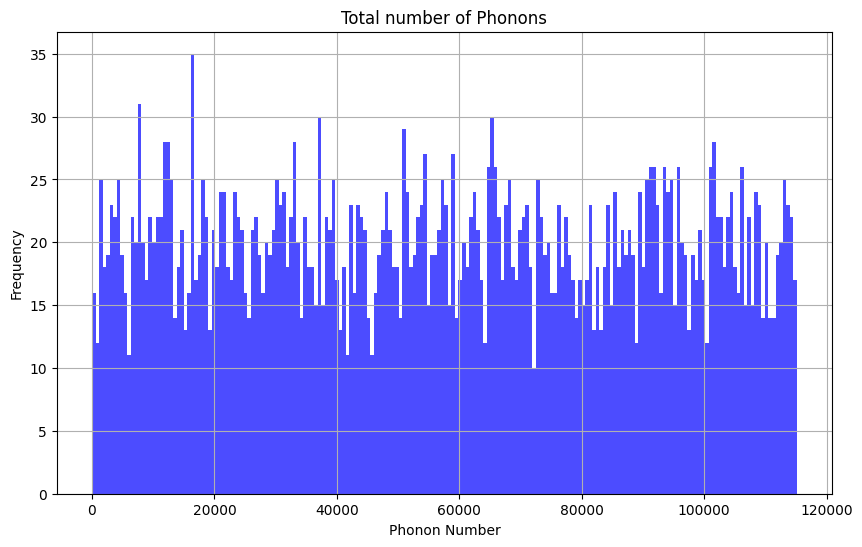

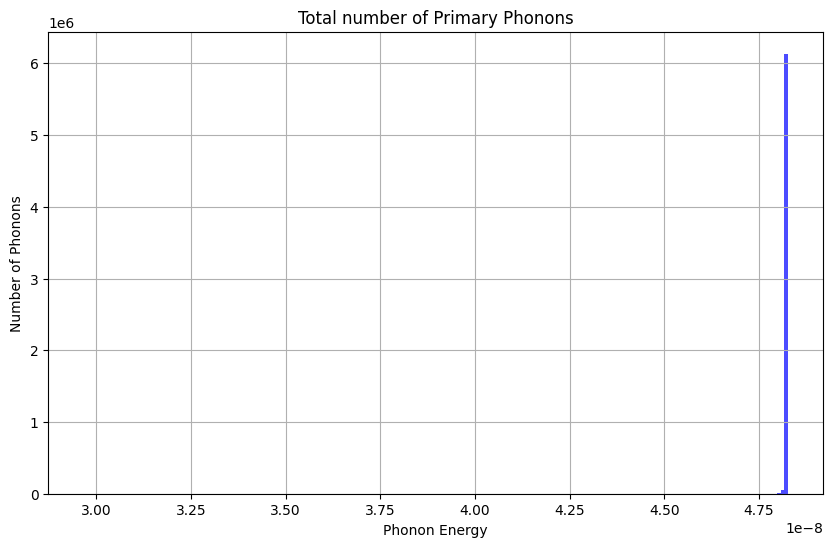

'\nplt.figure(figsize=(10, 6))\nplt.hist(df3[\'StartEnergy\'], bins=200, color=\'blue\', alpha=0.7)\nplt.title(\'Total number of Secondary Phonons\')\nplt.xlabel(\'Phonon Energy\')\nplt.ylabel(\'Number of Phonons/100\')\nplt.grid()\nplt.savefig("newLiNbO3params_CEvNS_spectrum_secondary_phonon_energy.pdf")\nplt.show()\n'

In [33]:
plt.figure(figsize=(10, 6))
plt.hist(df['totalPhonons'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Phonons')
plt.xlabel('Phonon Number')
plt.ylabel('Frequency')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_spectrum_phonon_number.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2['StartEnergy'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Primary Phonons')
plt.xlabel('Phonon Energy')
plt.ylabel('Number of Phonons')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_spectrum_primary_phonon_energy.pdf")
plt.show()
'''
plt.figure(figsize=(10, 6))
plt.hist(df3['StartEnergy'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Secondary Phonons')
plt.xlabel('Phonon Energy')
plt.ylabel('Number of Phonons/100')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_spectrum_secondary_phonon_energy.pdf")
plt.show()
'''

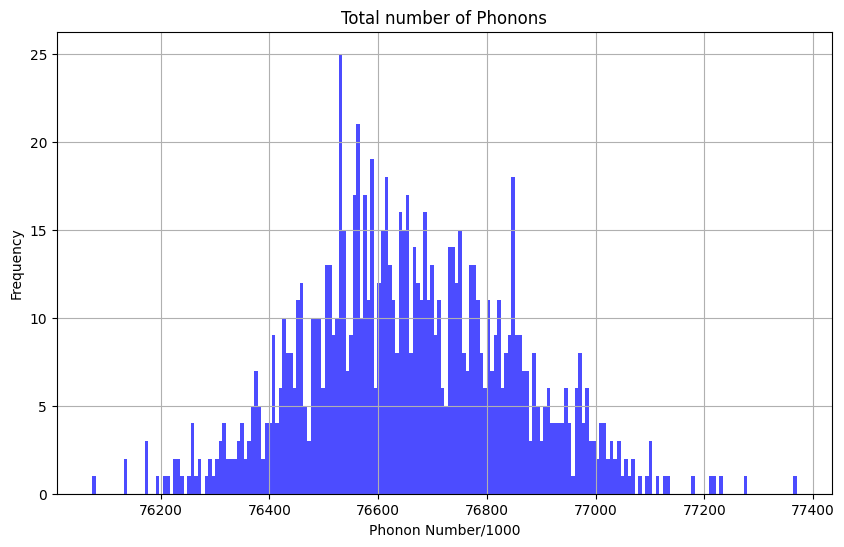

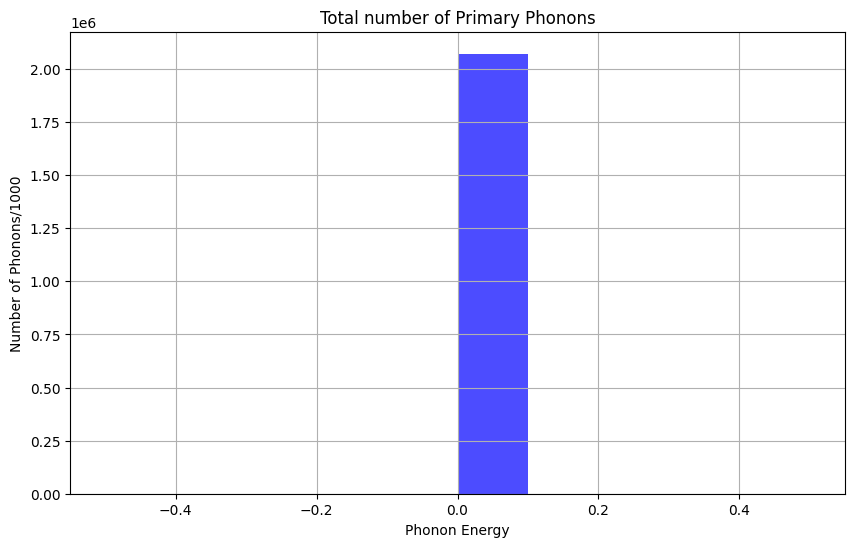

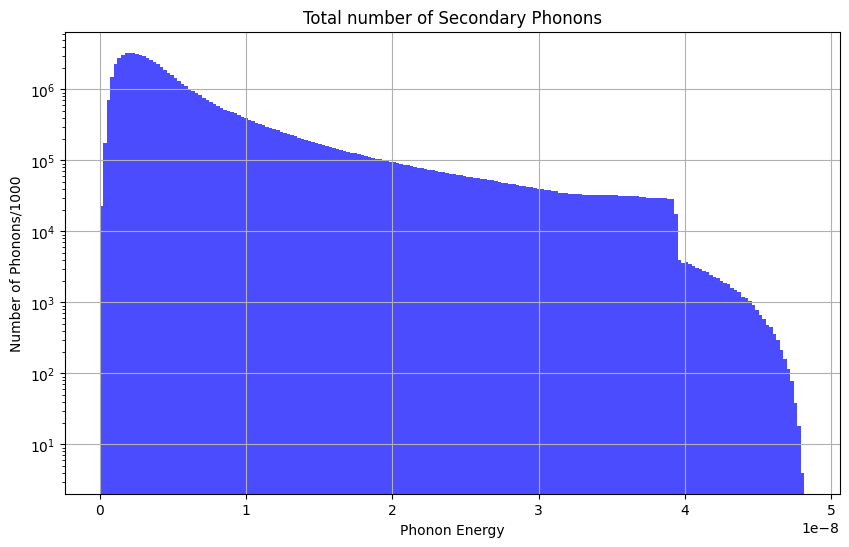

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(df_mono['totalPhonons'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Phonons')
plt.xlabel('Phonon Number/1000')
plt.ylabel('Frequency')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_mono_phonon_number.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2_mono['StartEnergy'], color='blue', alpha=0.7)
plt.title('Total number of Primary Phonons')
plt.xlabel('Phonon Energy')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_mono_phonon_number.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3_mono['StartEnergy'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Secondary Phonons')
plt.xlabel('Phonon Energy')
plt.ylabel('Number of Phonons/1000')
plt.yscale('log')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_mono_phonon_number.pdf")
plt.show()

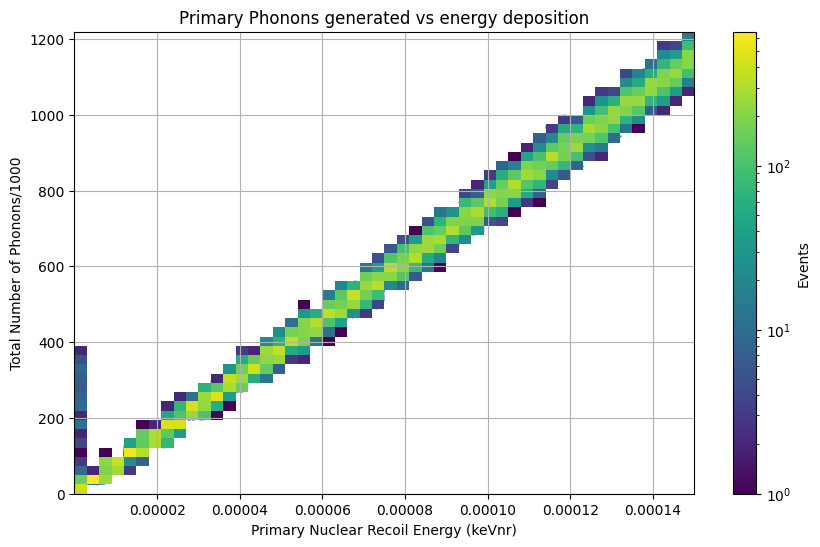

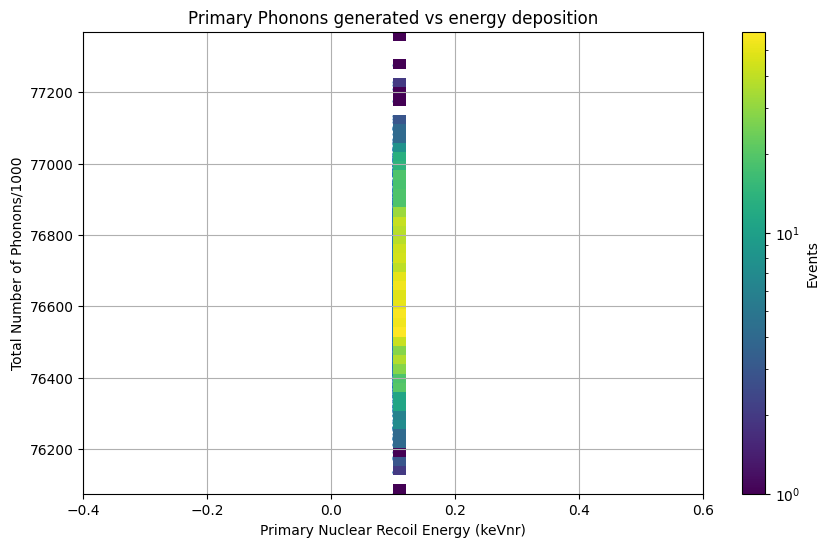

In [6]:
heatmap, xedges, yedges = np.histogram2d(df['PrimaryEnergy'], df['totalPhonons'], bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(df['PrimaryEnergy']*1000, df['totalPhonons'], alpha=0.5, s=1)
plt.title('Primary Phonons generated vs energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Total Number of Phonons/1000')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_spectrum_phononenergyvsnumber_morephonons.pdf")
plt.show()
'''
heatmap, xedges, yedges = np.histogram2d(df_mono['PrimaryEnergy'], df_mono['totalPhonons'], bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(df_mono['PrimaryEnergy'], df_mono['totalPhonons'], alpha=0.5, s=1)
plt.title('Primary Phonons generated vs energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Total Number of Phonons/1000')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_mono_phononenergyvs_number.pdf")
plt.show()
'''

In [18]:
from math import *
df2["momentum_mag"] = df2["StartMomX"]**2 + df2["StartMomY"]**2 + df2["StartMomZ"]**2
df2["mom_dir_x"] = df2["StartMomX"]/df2["momentum_mag"]**(1/2)
df2["mom_dir_y"] = df2["StartMomY"]/df2["momentum_mag"]**(1/2)
df2["mom_dir_z"] = df2["StartMomZ"]/df2["momentum_mag"]**(1/2)

df2_mono["momentum_mag"] = df2_mono["StartMomX"]**2 + df2_mono["StartMomY"]**2 + df2_mono["StartMomZ"]**2
df2_mono["mom_dir_x"] = df2_mono["StartMomX"]/df2_mono["momentum_mag"]**(1/2)
df2_mono["mom_dir_y"] = df2_mono["StartMomY"]/df2_mono["momentum_mag"]**(1/2)
df2_mono["mom_dir_z"] = df2_mono["StartMomZ"]/df2_mono["momentum_mag"]**(1/2)

df3["momentum_mag"] = df3["StartMomX"]**2 + df3["StartMomY"]**2 + df3["StartMomZ"]**2
df3["mom_dir_x"] = df3["StartMomX"]/df3["momentum_mag"]**(1/2)
df3["mom_dir_y"] = df3["StartMomY"]/df3["momentum_mag"]**(1/2)
df3["mom_dir_z"] = df3["StartMomZ"]/df3["momentum_mag"]**(1/2)

df3_mono["momentum_mag"] = df3_mono["StartMomX"]**2 + df3_mono["StartMomY"]**2 + df3_mono["StartMomZ"]**2
df3_mono["mom_dir_x"] = df3_mono["StartMomX"]/df3_mono["momentum_mag"]**(1/2)
df3_mono["mom_dir_y"] = df3_mono["StartMomY"]/df3_mono["momentum_mag"]**(1/2)
df3_mono["mom_dir_z"] = df3_mono["StartMomZ"]/df3_mono["momentum_mag"]**(1/2)

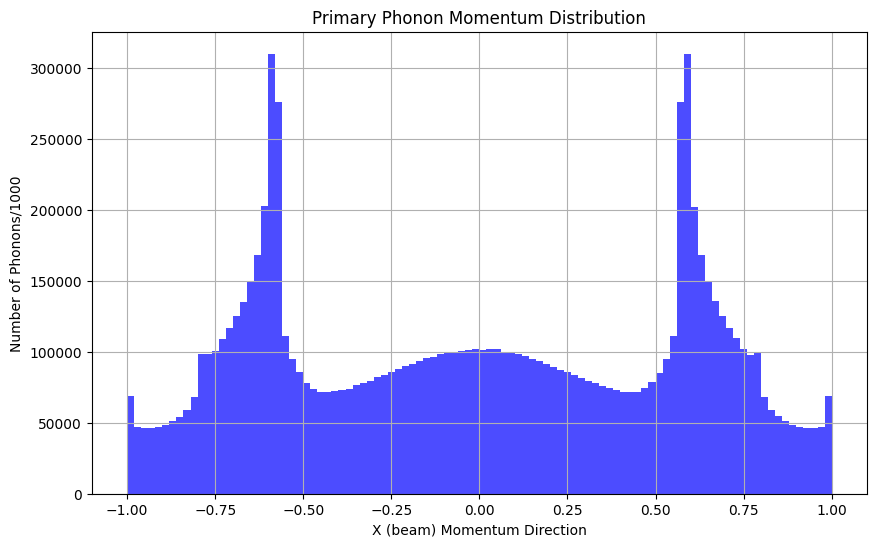

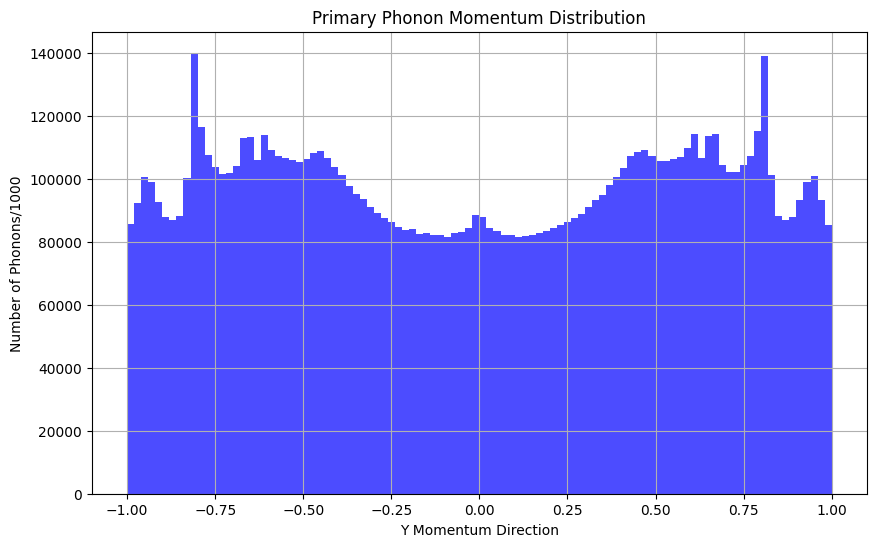

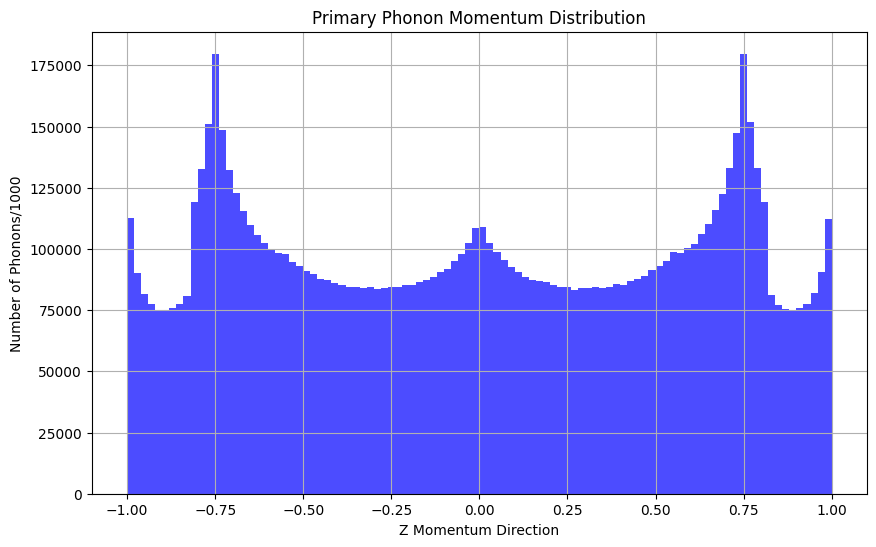

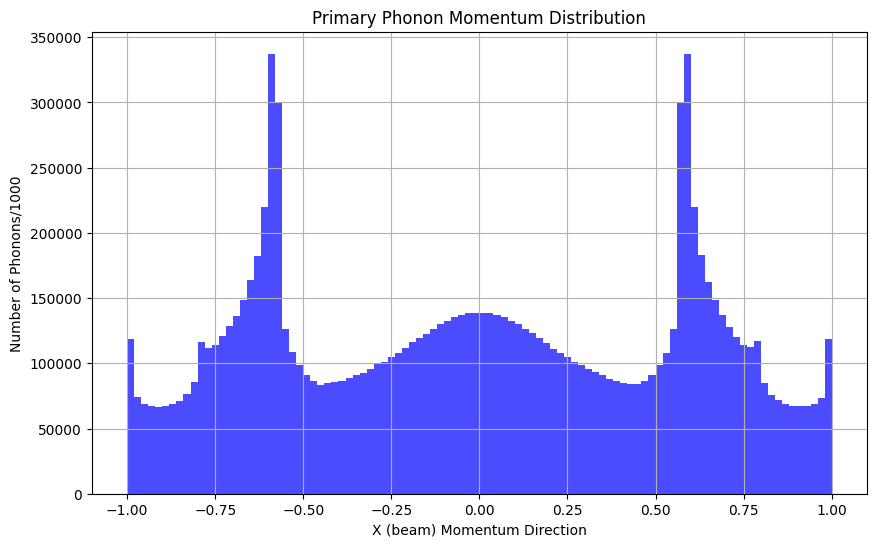

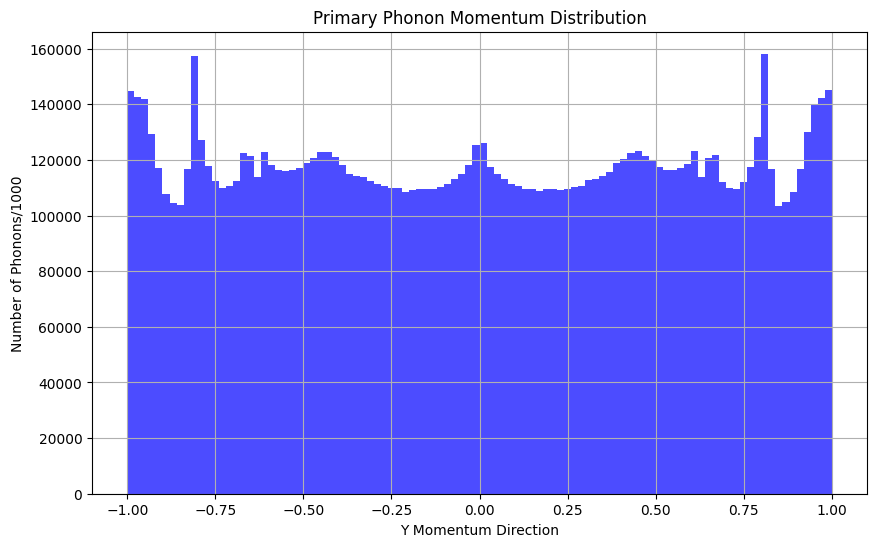

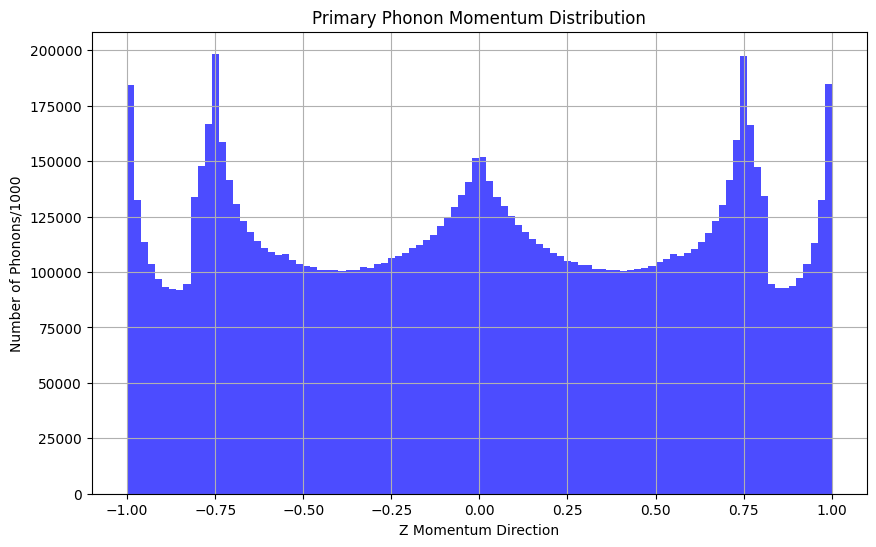

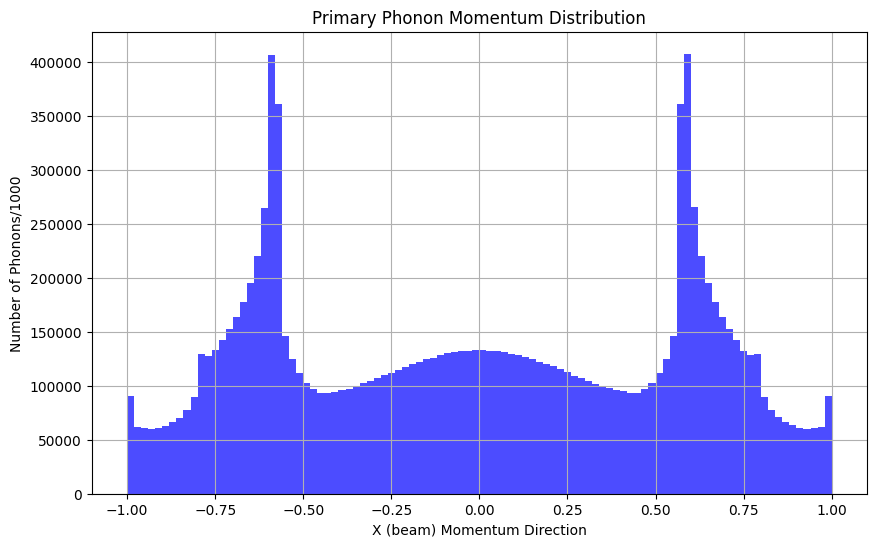

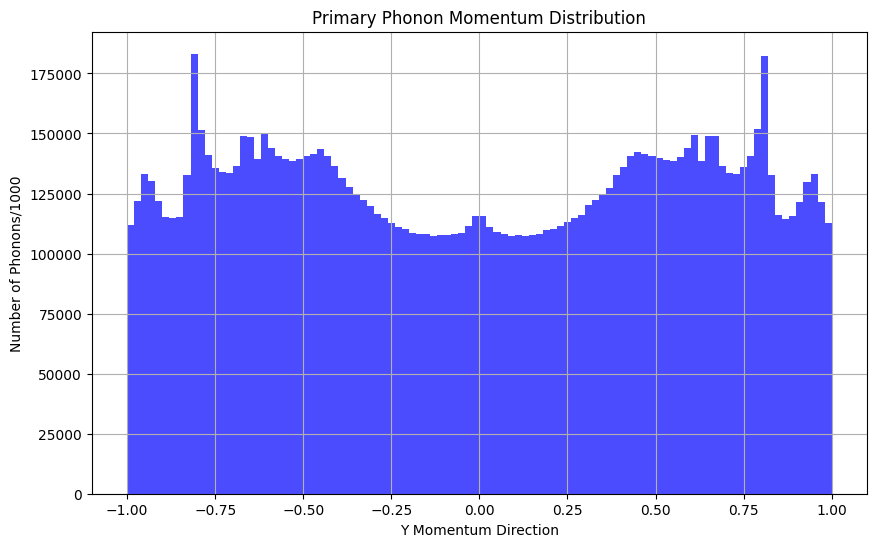

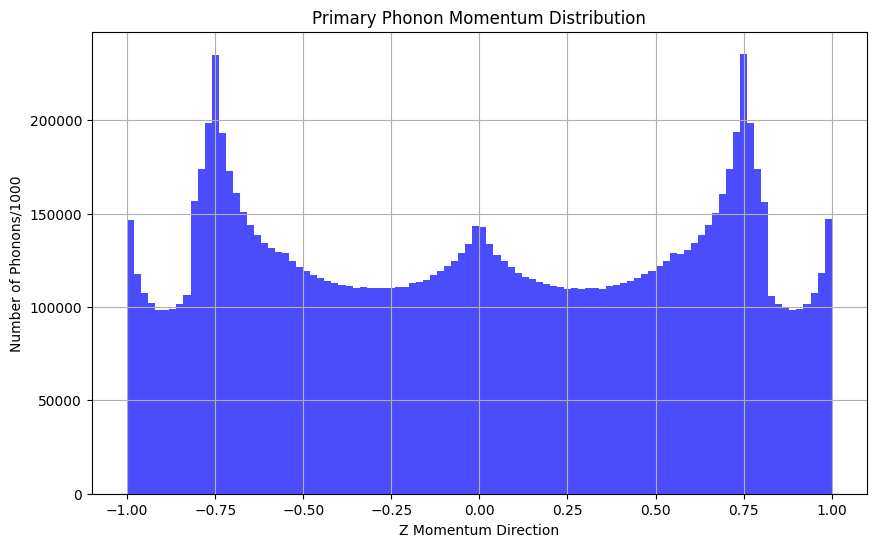

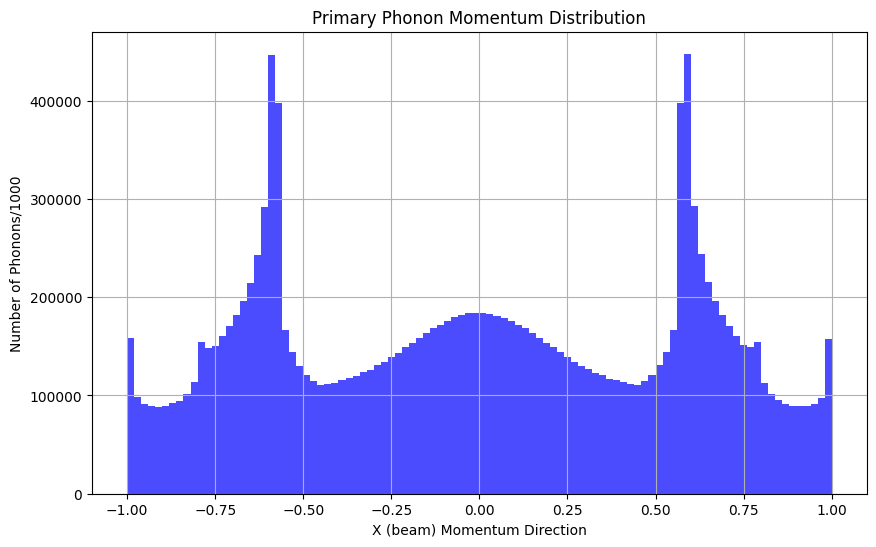

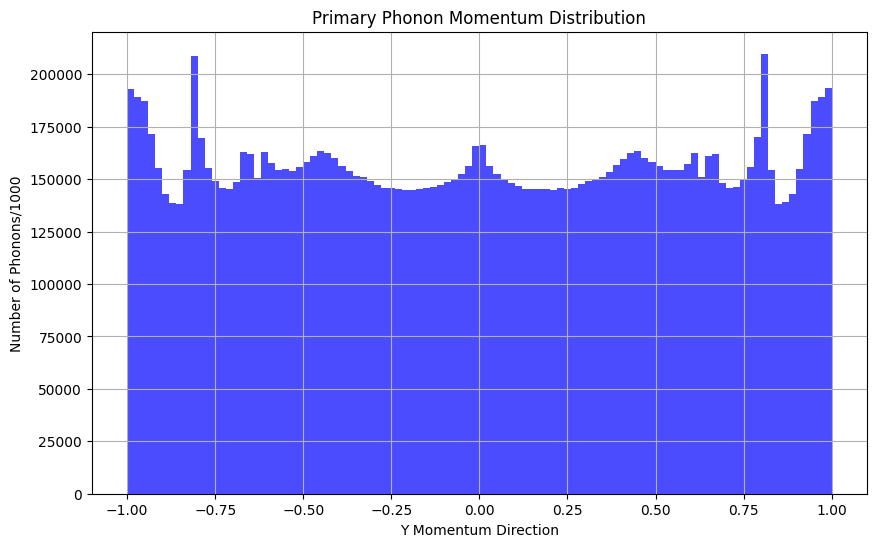

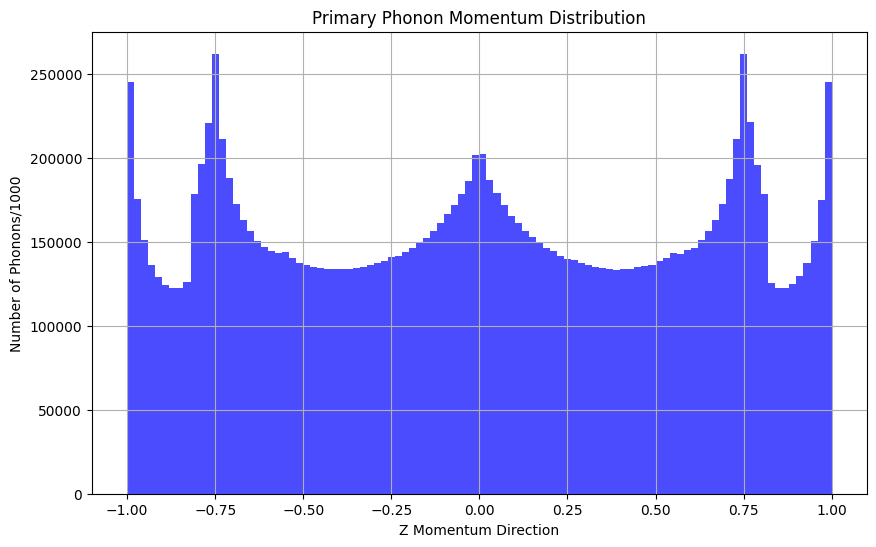

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(df2['mom_dir_x'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('X (beam) Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_simple_primary_phonon_momentumdirx_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2['mom_dir_y'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Y Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_primary_phonon_momentumdiry_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2['mom_dir_z'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Z Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_simple_primary_phonon_momentumdirz_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3['mom_dir_x'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('X (beam) Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_simple_secondary_phonon_momentumdirx_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3['mom_dir_y'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Y Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_simple_secondary_phonon_momentumdiry_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3['mom_dir_z'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Z Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_simple_secondary_phonon_momentumdirz_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2_mono['mom_dir_x'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('X (beam) Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_simple_primary_phonon_momentumdirx_mono.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2_mono['mom_dir_y'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Y Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_primary_phonon_momentumdiry_mono.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2_mono['mom_dir_z'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Z Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_simple_primary_phonon_momentumdirz_mono.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3_mono['mom_dir_x'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('X (beam) Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_simple_secondary_phonon_momentumdirx_mono.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3_mono['mom_dir_y'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Y Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_simple_secondary_phonon_momentumdiry_mono.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3_mono['mom_dir_z'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Z Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_simple_secondary_phonon_momentumdirz_mono.pdf")
plt.show()

In [45]:
#Add a column in the primary df counting the number of entries in each EventID in the primary/secondary counters
counts_prim = df2["EventID"].value_counts()
df["TotalPrimaryPhonons"] = df["EventID"].map(counts_prim).fillna(0).astype(int)
counts_sec = df3["EventID"].value_counts()
df["TotalSecondaryPhonons"] = df["EventID"].map(counts_sec).fillna(0).astype(int)

print(df)
'''
counts_prim_mono = df2_mono["EventID"].value_counts()
df_mono["TotalPrimaryPhonons"] = df_mono["EventID"].map(counts_prim_mono).fillna(0).astype(int)
counts_sec_mono = df3_mono["EventID"].value_counts()
df_mono["TotalSecondaryPhonons"] = df_mono["EventID"].map(counts_sec_mono).fillna(0).astype(int)

print(df_mono)
'''

       EventID  TrackID       PDGCode  PrimaryEnergy  PrimaryPosX  \
0          0.0      1.0  1.000411e+09       0.000018       -100.0   
1          1.0      1.0  1.000411e+09       0.000097       -100.0   
2          2.0      1.0  1.000411e+09       0.000143       -100.0   
3          3.0      1.0  1.000411e+09       0.000053       -100.0   
4          4.0      1.0  1.000411e+09       0.000118       -100.0   
...        ...      ...           ...            ...          ...   
31995  31995.0      1.0  1.000411e+09       0.000048       -100.0   
31996  31996.0      1.0  1.000411e+09       0.000117       -100.0   
31997  31997.0      1.0  1.000411e+09       0.000054       -100.0   
31998  31998.0      1.0  1.000411e+09       0.000016       -100.0   
31999  31999.0      1.0  1.000411e+09       0.000142       -100.0   

       PrimaryPosY  PrimaryPosZ  PrimaryMomentumX  PrimaryMomentumY  \
0              0.0          0.0               0.0               0.0   
1              0.0          0

'\ncounts_prim_mono = df2_mono["EventID"].value_counts()\ndf_mono["TotalPrimaryPhonons"] = df_mono["EventID"].map(counts_prim_mono).fillna(0).astype(int)\ncounts_sec_mono = df3_mono["EventID"].value_counts()\ndf_mono["TotalSecondaryPhonons"] = df_mono["EventID"].map(counts_sec_mono).fillna(0).astype(int)\n\nprint(df_mono)\n'

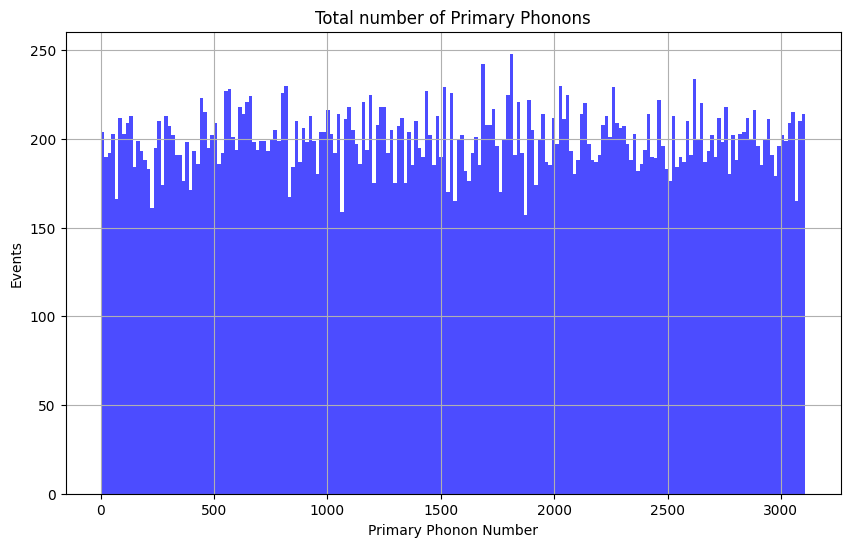

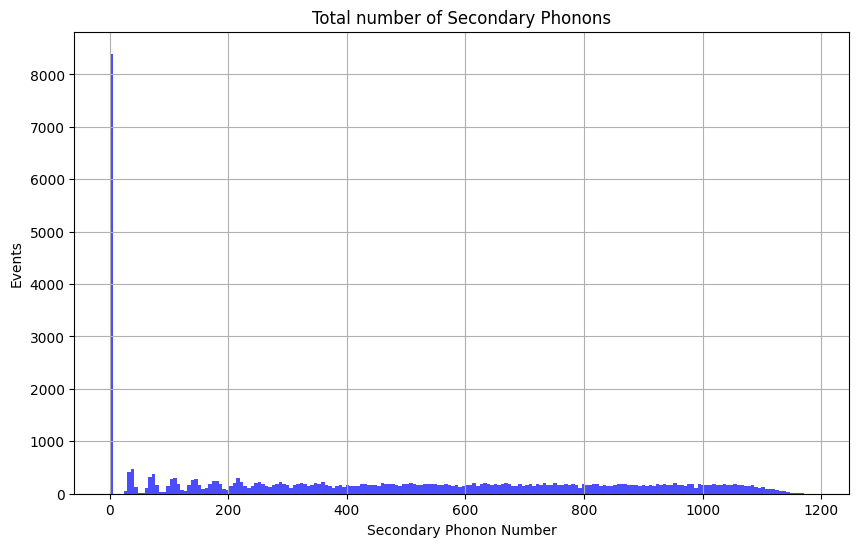

'\nplt.figure(figsize=(10, 6))\nplt.hist(df_mono["TotalPrimaryPhonons"], bins=200, color=\'blue\', alpha=0.7)\nplt.title(\'Total number of Primary Phonons\')\nplt.xlabel(\'Primary Phonon Number\')\nplt.ylabel(\'Events\')\nplt.grid()\nplt.savefig("newLiNbO3params_CEvNS_mono_primary_phonon_number.pdf")\nplt.show()\n\nplt.figure(figsize=(10, 6))\nplt.hist(df_mono[\'TotalSecondaryPhonons\'], bins=200, color=\'blue\', alpha=0.7)\nplt.title(\'Total number of Secondary Phonons\')\nplt.xlabel(\'Secondary Phonon Number\')\nplt.ylabel(\'Events\')\nplt.grid()\nplt.savefig("newLiNbO3params_CEvNS_mono_secondary_phonon_number.pdf")\nplt.show()\n'

In [37]:
plt.figure(figsize=(10, 6))
plt.hist(df["TotalPrimaryPhonons"], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Primary Phonons')
plt.xlabel('Primary Phonon Number')
plt.ylabel('Events')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_spectrum_primary_phonon_number_lowenergy.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df['TotalSecondaryPhonons'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Secondary Phonons')
plt.xlabel('Secondary Phonon Number')
plt.ylabel('Events')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_spectrum_secondary_phonon_number_lowenergy.pdf")
plt.show()
'''
plt.figure(figsize=(10, 6))
plt.hist(df_mono["TotalPrimaryPhonons"], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Primary Phonons')
plt.xlabel('Primary Phonon Number')
plt.ylabel('Events')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_mono_primary_phonon_number.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df_mono['TotalSecondaryPhonons'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Secondary Phonons')
plt.xlabel('Secondary Phonon Number')
plt.ylabel('Events')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_mono_secondary_phonon_number.pdf")
plt.show()
'''

In [47]:
#make a few plots, calcs using the scaled phonon values (edep only reasonable here without downconversion/scattering)
phonon_scale = 100
primary_esum = df2.groupby("EventID")["StartEnergy"].sum()*phonon_scale*1e3
df["PrimaryPhononEdep"] = df["EventID"].map(primary_esum).fillna(0).astype(float)
#slightly more complex for secondary, need to take into account the individual phonon energy as not identical
secondary_esum = df3.groupby("EventID")["StartEnergy"].sum()*phonon_scale*1e3 #sum energy and convert to keV
df["SecondaryPhononEdep"] = df["EventID"].map(secondary_esum).fillna(0).astype(float) 

print(df)
'''
primary_esum_mono = df2_mono.groupby("EventID")["StartEnergy"].sum()*phonon_scale*1e3
df_mono["PrimaryPhononEdep"] = df_mono["EventID"].map(primary_esum_mono).fillna(0).astype(float)
#slightly more complex for secondary, need to take into account the individual phonon energy as not identical
secondary_esum_mono = df3_mono.groupby("EventID")["StartEnergy"].sum()*phonon_scale*1e3 #sum and convert to keV
df_mono["SecondaryPhononEdep"] = df_mono["EventID"].map(secondary_esum_mono).fillna(0).astype(float) 
print(df_mono)
'''

       EventID  TrackID       PDGCode  PrimaryEnergy  PrimaryPosX  \
0          0.0      1.0  1.000411e+09       0.000018       -100.0   
1          1.0      1.0  1.000411e+09       0.000097       -100.0   
2          2.0      1.0  1.000411e+09       0.000143       -100.0   
3          3.0      1.0  1.000411e+09       0.000053       -100.0   
4          4.0      1.0  1.000411e+09       0.000118       -100.0   
...        ...      ...           ...            ...          ...   
31995  31995.0      1.0  1.000411e+09       0.000048       -100.0   
31996  31996.0      1.0  1.000411e+09       0.000117       -100.0   
31997  31997.0      1.0  1.000411e+09       0.000054       -100.0   
31998  31998.0      1.0  1.000411e+09       0.000016       -100.0   
31999  31999.0      1.0  1.000411e+09       0.000142       -100.0   

       PrimaryPosY  PrimaryPosZ  PrimaryMomentumX  PrimaryMomentumY  \
0              0.0          0.0               0.0               0.0   
1              0.0          0

'\nprimary_esum_mono = df2_mono.groupby("EventID")["StartEnergy"].sum()*phonon_scale*1e3\ndf_mono["PrimaryPhononEdep"] = df_mono["EventID"].map(primary_esum_mono).fillna(0).astype(float)\n#slightly more complex for secondary, need to take into account the individual phonon energy as not identical\nsecondary_esum_mono = df3_mono.groupby("EventID")["StartEnergy"].sum()*phonon_scale*1e3 #sum and convert to keV\ndf_mono["SecondaryPhononEdep"] = df_mono["EventID"].map(secondary_esum_mono).fillna(0).astype(float) \nprint(df_mono)\n'

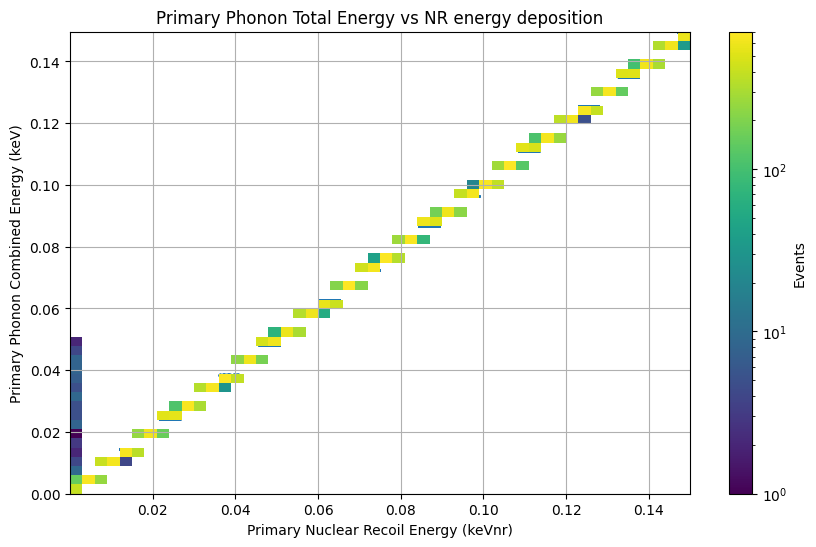

'\n\nheatmap, xedges, yedges = np.histogram2d(df_mono[\'PrimaryEnergy\']*1000, df_mono[\'PrimaryPhononEdep\'], bins=50)\n#heatmap = heatmap / heatmap.sum()\n#heatmap = heatmap / 5000000.0\nheatmap = np.ma.masked_where(heatmap == 0, heatmap) \n\nplt.figure(figsize=(10, 6))\nplt.scatter(df_mono[\'PrimaryEnergy\']*1000, df_mono[\'PrimaryPhononEdep\'], alpha=0.5, s=1)\nplt.title(\'Primary Phonon Total Energy vs NR energy deposition\')\nplt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")\nplt.colorbar(label="Events")\nplt.xlabel(\'Primary Nuclear Recoil Energy (keVnr)\')\nplt.ylabel(\'Primary Phonon Combined Energy (keV)\')\nplt.grid()\nplt.savefig("newLiNbO3params_CEvNS_mono_primaryedepenergy.pdf")\nplt.show()\n'

In [48]:
heatmap, xedges, yedges = np.histogram2d(df['PrimaryEnergy']*1000, df['PrimaryPhononEdep'], bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap)

plt.figure(figsize=(10, 6))
plt.scatter(df['PrimaryEnergy']*1000, df['PrimaryPhononEdep'], alpha=0.5, s=1)
plt.title('Primary Phonon Total Energy vs NR energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Primary Phonon Combined Energy (keV)')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_spectrum_primaryedepenergy_lowenergy_phononscaled.pdf")
plt.show()

'''

heatmap, xedges, yedges = np.histogram2d(df_mono['PrimaryEnergy']*1000, df_mono['PrimaryPhononEdep'], bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(df_mono['PrimaryEnergy']*1000, df_mono['PrimaryPhononEdep'], alpha=0.5, s=1)
plt.title('Primary Phonon Total Energy vs NR energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Primary Phonon Combined Energy (keV)')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_mono_primaryedepenergy.pdf")
plt.show()
'''

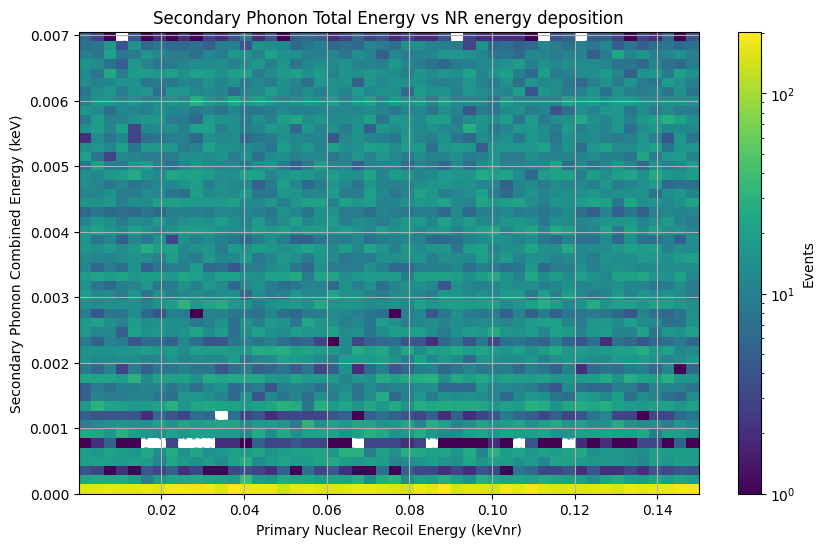

'\nheatmap, xedges, yedges = np.histogram2d(df_mono[\'PrimaryEnergy\']*1000, df_mono[\'SecondaryPhononEdep\'], bins=50)\n#heatmap = heatmap / heatmap.sum()\n#heatmap = heatmap / 5000000.0\nheatmap = np.ma.masked_where(heatmap == 0, heatmap) \n\nplt.figure(figsize=(10, 6))\nplt.scatter(df_mono[\'PrimaryEnergy\']*1000, df_mono[\'SecondaryPhononEdep\'], alpha=0.5, s=1)\nplt.title(\'Secondary Phonon Total Energy vs NR energy deposition\')\nplt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")\nplt.colorbar(label="Events")\nplt.xlabel(\'Primary Nuclear Recoil Energy (keVnr)\')\nplt.ylabel(\'Secondary Phonon Combined Energy (keV)\')\nplt.grid()\nplt.savefig("newLiNbO3params_CEvNS_mono_secondayryedepenergy.pdf")\nplt.show()\n'

In [40]:
heatmap, xedges, yedges = np.histogram2d(df['PrimaryEnergy']*1000, df['SecondaryPhononEdep'], bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap)

plt.figure(figsize=(10, 6))
plt.scatter(df['PrimaryEnergy']*1000, df['SecondaryPhononEdep'], alpha=0.5, s=1)
plt.title('Secondary Phonon Total Energy vs NR energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Secondary Phonon Combined Energy (keV)')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_spectrum_secondaryedepenergy.pdf")
plt.show()
'''
heatmap, xedges, yedges = np.histogram2d(df_mono['PrimaryEnergy']*1000, df_mono['SecondaryPhononEdep'], bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(df_mono['PrimaryEnergy']*1000, df_mono['SecondaryPhononEdep'], alpha=0.5, s=1)
plt.title('Secondary Phonon Total Energy vs NR energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Secondary Phonon Combined Energy (keV)')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_mono_secondayryedepenergy.pdf")
plt.show()
'''

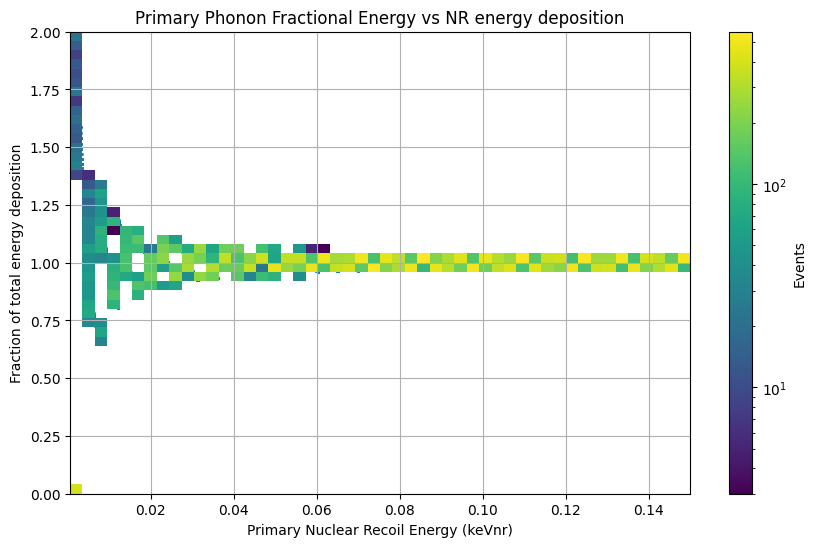

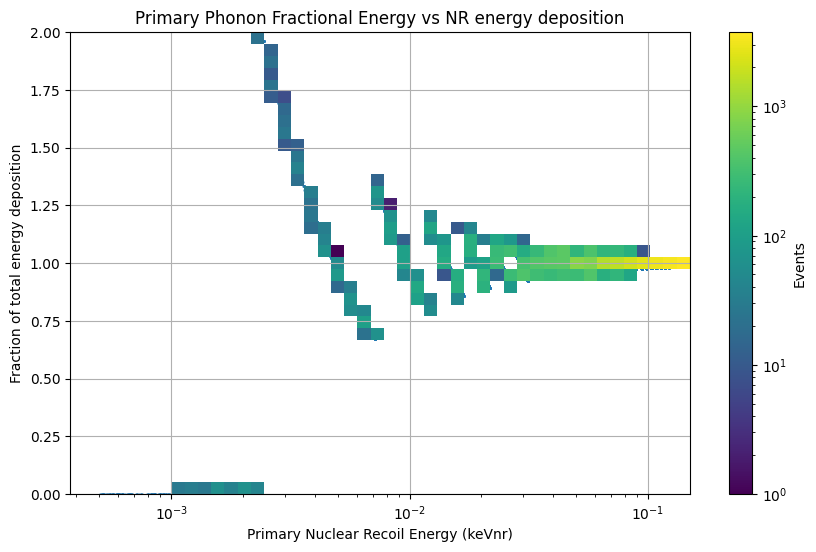

'\nheatmap, xedges, yedges = np.histogram2d(df_mono[\'PrimaryEnergy\']*1000, df_mono[\'PrimaryPhononEdep\']/(df_mono[\'PrimaryEnergy\']*1000), bins=50)\n#heatmap = heatmap / heatmap.sum()\n#heatmap = heatmap / 5000000.0\nheatmap = np.ma.masked_where(heatmap == 0, heatmap) \n\nplt.figure(figsize=(10, 6))\nplt.scatter(df_mono[\'PrimaryEnergy\']*1000, df_mono[\'PrimaryPhononEdep\']/(df_mono[\'PrimaryEnergy\']*1000), alpha=0.5, s=1)\nplt.title(\'Primary Phonon Fractional Energy vs NR energy deposition\')\nplt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")\nplt.colorbar(label="Events")\nplt.xlabel(\'Primary Nuclear Recoil Energy (keVnr)\')\nplt.ylabel(\'Fraction of total energy deposition\')\nplt.grid()\nplt.savefig("newLiNbO3params_CEvNS_mono_fracprimaryphononedepenergy_vs_nredep.pdf")\nplt.show()\n'

In [49]:
mask = df['PrimaryPhononEdep']/(df['PrimaryEnergy']*1000) < 4
df_masked = df[mask]

heatmap, xedges, yedges = np.histogram2d(df_masked['PrimaryEnergy']*1000, df_masked['PrimaryPhononEdep']/(df_masked['PrimaryEnergy']*1000), bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap)

plt.figure(figsize=(10, 6))
plt.scatter(df_masked['PrimaryEnergy']*1000, df_masked['PrimaryPhononEdep']/(df_masked['PrimaryEnergy']*1000), alpha=0.5, s=1)
plt.title('Primary Phonon Fractional Energy vs NR energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Fraction of total energy deposition')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_spectrum_fracprimaryphononenergy_vs_nredep_phononscaled.pdf")
plt.show()

bins_x = np.logspace(np.log10(1e-3), np.log10(0.15), num=40)
bins_y = np.linspace(0, 2.0, 40)

heatmap, xedges, yedges = np.histogram2d(df_masked['PrimaryEnergy']*1000, df_masked['PrimaryPhononEdep']/(df_masked['PrimaryEnergy']*1000), bins=[bins_x, bins_y])
plt.figure(figsize=(10, 6))
plt.scatter(df_masked['PrimaryEnergy']*1000, df_masked['PrimaryPhononEdep']/(df_masked['PrimaryEnergy']*1000), alpha=0.5, s=1)
plt.title('Primary Phonon Fractional Energy vs NR energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Fraction of total energy deposition')
plt.grid()
plt.xscale('log')
plt.savefig("newLiNbO3params_CEvNS_spectrum_logbins_fracenergy_phononscaled.pdf")
plt.show()
'''
heatmap, xedges, yedges = np.histogram2d(df_mono['PrimaryEnergy']*1000, df_mono['PrimaryPhononEdep']/(df_mono['PrimaryEnergy']*1000), bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(df_mono['PrimaryEnergy']*1000, df_mono['PrimaryPhononEdep']/(df_mono['PrimaryEnergy']*1000), alpha=0.5, s=1)
plt.title('Primary Phonon Fractional Energy vs NR energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Fraction of total energy deposition')
plt.grid()
plt.savefig("newLiNbO3params_CEvNS_mono_fracprimaryphononedepenergy_vs_nredep.pdf")
plt.show()
'''

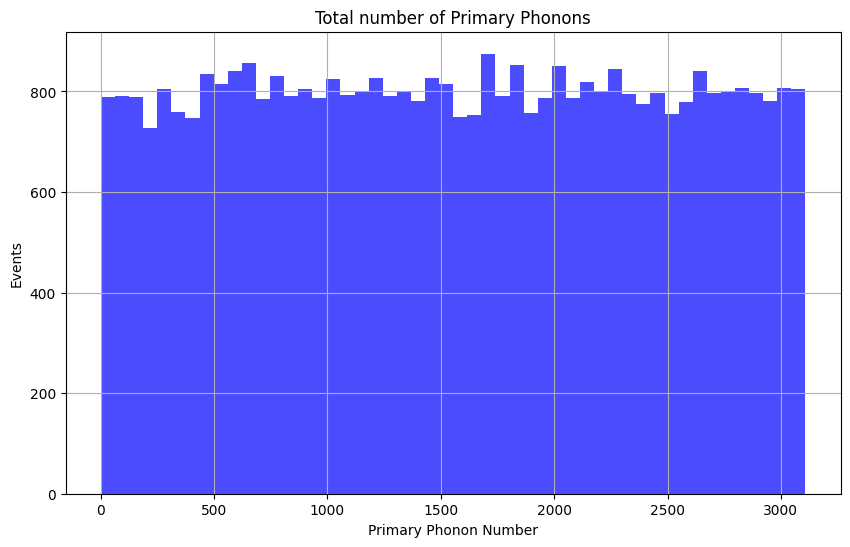

In [43]:
plt.figure(figsize=(10, 6))
plt.hist(df_masked["TotalPrimaryPhonons"], bins=50, color='blue', alpha=0.7)
plt.title('Total number of Primary Phonons')
plt.xlabel('Primary Phonon Number')
plt.ylabel('Events')
plt.grid()
#plt.savefig("newLiNbO3params_CEvNS_spectrum_primary_phonon_number.pdf")
plt.show()


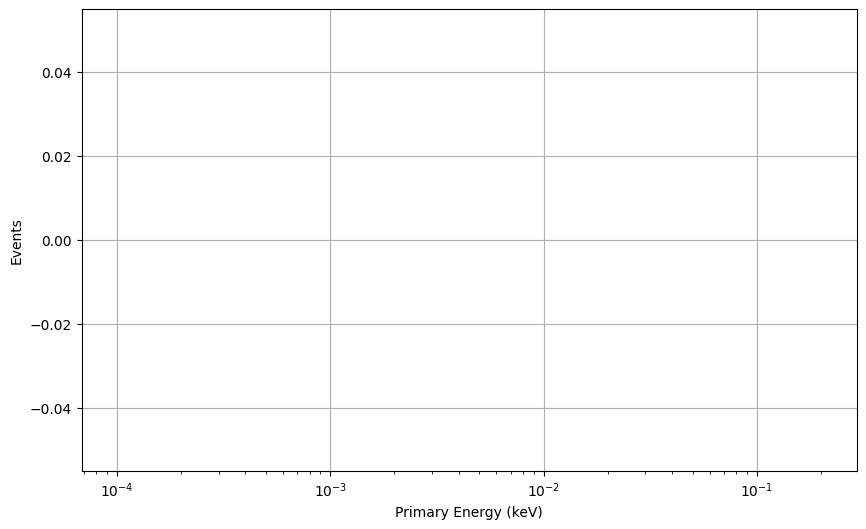

In [32]:
mask = df['PrimaryPhononEdep']/(df['PrimaryEnergy']*1000) > 1.05

df_mask = df[mask]
bins = np.logspace(np.log10(0.0001), np.log10(0.2))
plt.figure(figsize=(10, 6))
plt.hist(df_mask['PrimaryEnergy']*1000, bins=bins, color='blue', alpha=0.7)
#plt.title('Total number of Secondary Phonons')
plt.xlabel('Primary Energy (keV)')
plt.ylabel('Events')
plt.xscale('log')
plt.grid()
#plt.savefig("newLiNbO3params_CEvNS_mono_secondary_phonon_number.pdf")
plt.show()

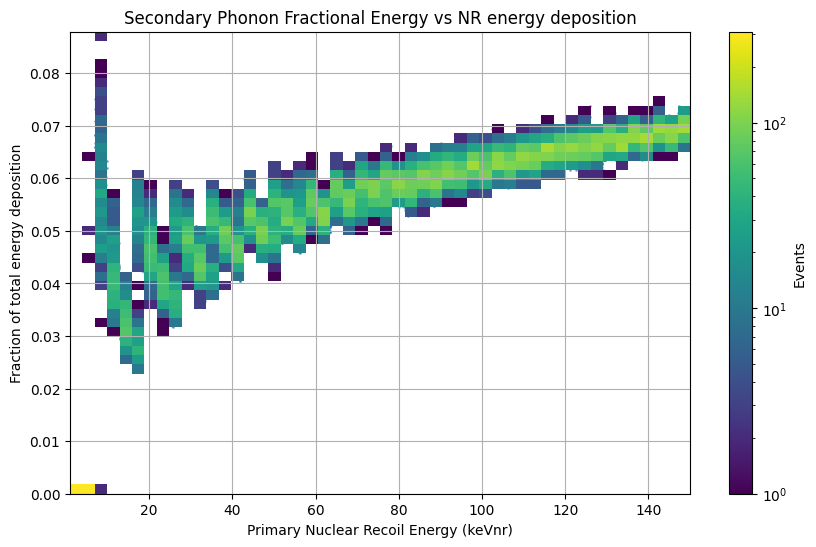

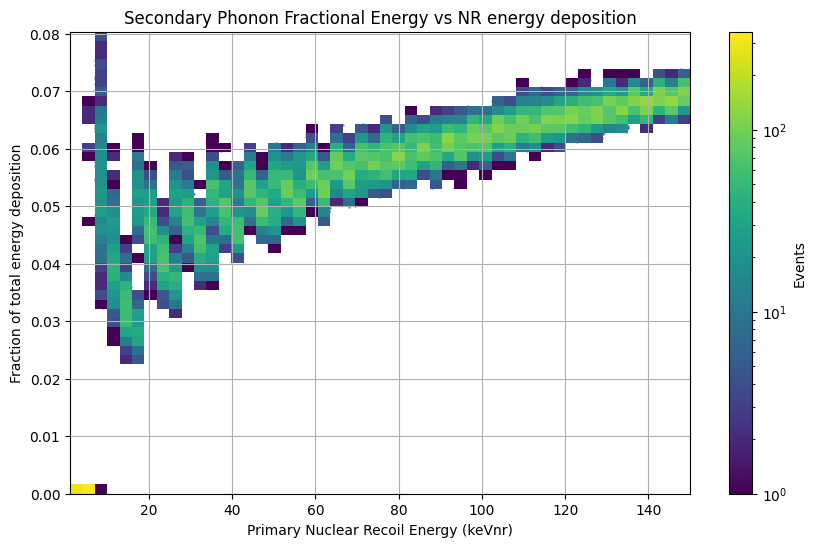

In [12]:
mask = df['PrimaryEnergy'] > 0.001
df_mask = df[mask]

heatmap, xedges, yedges = np.histogram2d(df_mask['PrimaryEnergy']*1000, df_mask['SecondaryPhononEdep']/(df_mask['PrimaryEnergy']*1000), bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap)

plt.figure(figsize=(10, 6))
plt.scatter(df_mask['PrimaryEnergy']*1000, df_mask['SecondaryPhononEdep']/(df_mask['PrimaryEnergy']*1000), alpha=0.5, s=1)
plt.title('Secondary Phonon Fractional Energy vs NR energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Fraction of total energy deposition')
plt.grid()
plt.savefig("CEvNS_simple_fracsecondaryphononenergy_vs_nredep_spectrum.pdf")
plt.show()

mono_mask = df_mono['PrimaryEnergy'] > 0.001
df_mono_mask = df_mono[mono_mask]

heatmap, xedges, yedges = np.histogram2d(df_mono_mask['PrimaryEnergy']*1000, df_mono_mask['SecondaryPhononEdep']/(df_mono_mask['PrimaryEnergy']*1000), bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(df_mono_mask['PrimaryEnergy']*1000, df_mono_mask['SecondaryPhononEdep']/(df_mono_mask['PrimaryEnergy']*1000), alpha=0.5, s=1)
plt.title('Secondary Phonon Fractional Energy vs NR energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Fraction of total energy deposition')
plt.grid()
plt.savefig("CEvNS_simple_fracsecondaryphononenergy_vs_nredep_mono_updatedDebyeTemp.pdf")
plt.show()

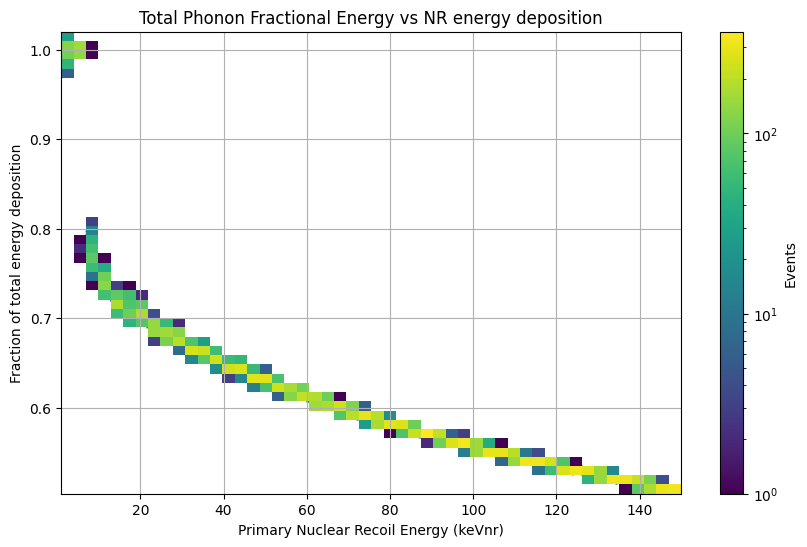

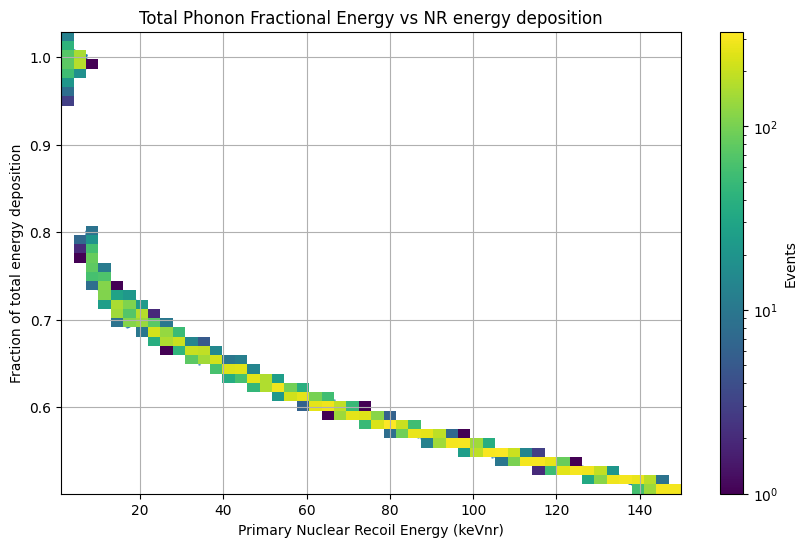

In [13]:
#mask = df['PrimaryEnergy'] > 0.001
#df_mask = df[mask]

heatmap, xedges, yedges = np.histogram2d(df_mask['PrimaryEnergy']*1000, (df_mask['PrimaryPhononEdep'] + df_mask['SecondaryPhononEdep'])/(df_mask['PrimaryEnergy']*1000), bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap)

plt.figure(figsize=(10, 6))
plt.scatter(df_mask['PrimaryEnergy']*1000, (df_mask['PrimaryPhononEdep'] + df_mask['SecondaryPhononEdep'])/(df_mask['PrimaryEnergy']*1000), alpha=0.5, s=1)
plt.title('Total Phonon Fractional Energy vs NR energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Fraction of total energy deposition')
plt.grid()
plt.savefig("CEvNS_simple_fractotalphononenergy_vs_nredep_spectrum.pdf")
plt.show()

heatmap, xedges, yedges = np.histogram2d(df_mono_mask['PrimaryEnergy']*1000, (df_mono_mask['PrimaryPhononEdep'] + df_mono_mask['SecondaryPhononEdep'])/(df_mono_mask['PrimaryEnergy']*1000), bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(df_mono_mask['PrimaryEnergy']*1000, (df_mono_mask['PrimaryPhononEdep'] + df_mono_mask['SecondaryPhononEdep'])/(df_mono_mask['PrimaryEnergy']*1000), alpha=0.5, s=1)
plt.title('Total Phonon Fractional Energy vs NR energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Fraction of total energy deposition')
plt.grid()
plt.savefig("CEvNS_simple_fractotalphononenergy_vs_nredep_updatedDebyeTemp.pdf")
plt.show()

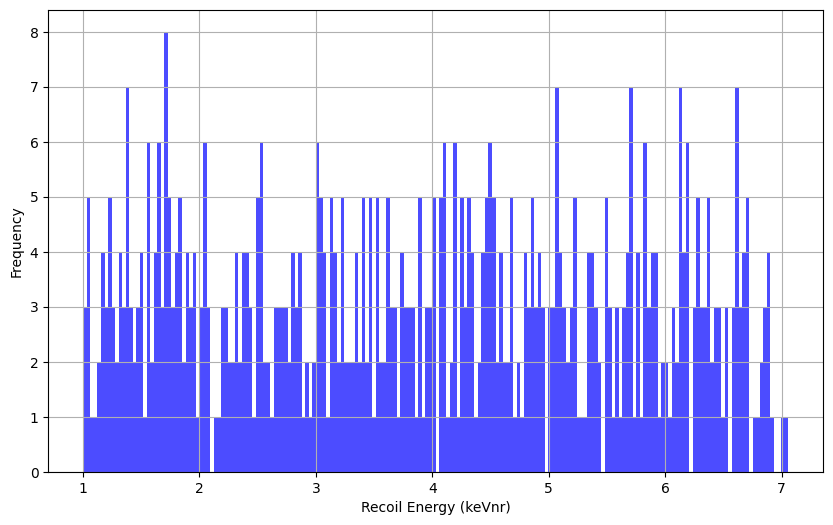

In [31]:
mask_odd = (df_mask['PrimaryPhononEdep'] + df_mask['SecondaryPhononEdep'])/(df_mask['PrimaryEnergy']*1000) > 0.9
df_mask_more = df_mask[mask_odd]

plt.figure(figsize=(10, 6))
plt.hist(df_mask_more['PrimaryEnergy']*1000.0, bins=200, color='blue', alpha=0.7)
plt.title('')
plt.xlabel('Recoil Energy (keVnr)')
plt.ylabel('Frequency')
plt.grid()
#plt.savefig("CEvNS_simple_phonon_number_spectrum.pdf")
plt.show()
